In [3]:
import scanpy as sc
import numpy as np
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.sparse import issparse

In [4]:
# load data
data_dir = '../data/frangieh/'
adata = sc.read_h5ad(data_dir + 'adata_preprocessed.h5ad')

In [18]:
# split data by condition
adata_control = adata[adata.obs['condition'] == 'Control']
adata_ifng = adata[adata.obs['condition'] == 'IFNγ']
adata_coculture = adata[adata.obs['condition'] == 'Co-culture']

In [4]:
all_data = {"control": adata_control, "ifng": adata_ifng, "coculture": adata_coculture}

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


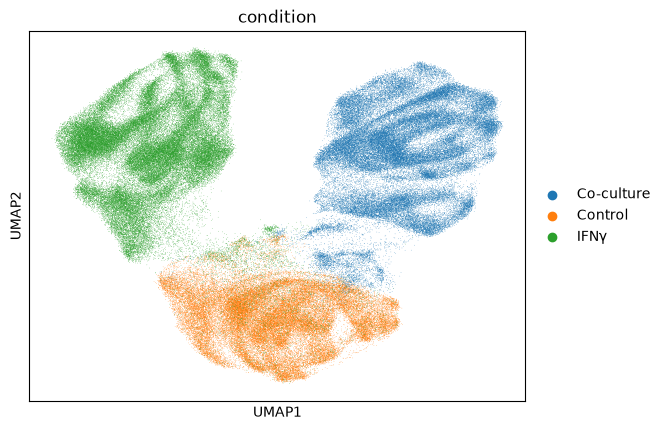

In [5]:
# Create umap colored by condition
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.umap(adata)
sc.pl.umap(adata, color="condition")

In [5]:
# Subset anndata to Highly Variable Genes (HVGs) to reduce noise
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

In [6]:
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = 'condition',
    pert_key: str = 'perturbation',
    control_label: str = 'control',
    min_cells: int = 15,
    pseudocount: float = 1.0,
    data_type: str = 'counts',
) -> ad.AnnData:
    """
    Computes pseudobulk log2 fold changes (LFC) per perturbation relative to controls within each condition.
    
    Parameters
    ----------
    adata : ad.AnnData
        Single-cell AnnData object (log1p normalized or raw counts in .X).
    cond_key : str
        Observation key for experimental conditions (e.g., 'Control', 'IFNγ', 'Co-culture').
    pert_key : str
        Observation key for perturbation target labels.
    control_label : str
        Label indicating unperturbed control cells within pert_key.
    min_cells : int
        Minimum number of cells required per perturbation group to keep it.
    pseudocount : float
        Small offset added to linear means to prevent zero-division in log2 ratio.
    data_type : str
        Either 'counts' or 'log1p'. Specifies the type of data in adata.X.

    Returns
    -------
    ad.AnnData
        Pseudobulk AnnData object containing Log2 Fold Changes in .X,
        retained perturbation/condition metadata in .obs, and gene annotations in .var.
    """

    # 1. Clean up labels
    obs_df = adata.obs.copy()
    obs_df[pert_key] = obs_df[pert_key].astype(str).str.strip().str.lower()
    ctrl_label_clean = str(control_label).strip().lower()

    # 2. Filter perturbations with fewer than min_dataset_cells across the entire dataset
    if min_cells > 0:
        dataset_counts = obs_df[pert_key].value_counts()
        valid_dataset_perts = dataset_counts[
            dataset_counts >= min_cells
        ].index
        cell_mask = obs_df[pert_key].isin(valid_dataset_perts).values

        adata_filtered = adata[cell_mask].copy()
        obs_df = obs_df[cell_mask].copy()
    else:
        adata_filtered = adata.copy()
    
    # 3. Extract expression matrix (linearize if log1p) or use raw counts
    if data_type == "log1p":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.expm1(X_linear.data)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.expm1(
                np.asarray(adata_filtered.X, dtype=np.float64)
            )
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    elif data_type == "counts":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.asarray(adata_filtered.X, dtype=np.float64)
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    else:
        X_linear = adata_filtered.X.copy()

    lfc_matrices = []
    obs_metadata_list = []

    # 4. Process each condition independently without per-condition min_cells filtering
    for cond_val, cond_obs in obs_df.groupby(cond_key):
        cond_indices = cond_obs.index
        cond_mask = obs_df.index.isin(cond_indices)

        # Extract linear matrix subset for this condition
        X_cond = X_linear[cond_mask, :]
        cond_perts = obs_df.loc[cond_indices, pert_key].values
        pert_counts_in_cond = cond_obs[pert_key].value_counts()

        # Locate control cells in this condition
        ctrl_mask = cond_perts == ctrl_label_clean
        if not np.any(ctrl_mask):
            print(
                f"Skipping condition '{cond_val}': No control cells"
                f" ('{ctrl_label_clean}') found."
            )
            continue

        # Compute mean linear profile for control
        if issparse(X_cond):
            ctrl_mean = np.asarray(X_cond[ctrl_mask, :].mean(axis=0)).ravel()
        else:
            ctrl_mean = X_cond[ctrl_mask, :].mean(axis=0)

        # Target all non-control perturbations present in this condition
        target_perts = [
            p for p in np.unique(cond_perts) if p != ctrl_label_clean
        ]

        cond_lfc_list = []
        retained_obs = []

        for pert in target_perts:
            p_mask = cond_perts == pert

            if issparse(X_cond):
                p_mean = np.asarray(X_cond[p_mask, :].mean(axis=0)).ravel()
            else:
                p_mean = X_cond[p_mask, :].mean(axis=0)

            # Calculate standard Log2 Fold Change
            lfc = np.log2((p_mean + pseudocount) / (ctrl_mean + pseudocount))
            cond_lfc_list.append(lfc)

            # Metadata tracking
            sample_obs_row = cond_obs[
                cond_obs[pert_key] == pert
            ].iloc[0].to_dict()
            sample_obs_row["n_cells_pseudobulk"] = pert_counts_in_cond[pert]
            retained_obs.append(sample_obs_row)

        if len(cond_lfc_list) > 0:
            lfc_matrices.append(np.vstack(cond_lfc_list))
            obs_metadata_list.extend(retained_obs)

    if not lfc_matrices:
        raise ValueError(
            "No valid perturbation groups could be computed across conditions."
        )

    # 5. Concatenate and return AnnData
    final_lfc_matrix = np.vstack(lfc_matrices)
    final_obs_df = pd.DataFrame(obs_metadata_list)
    final_obs_df.index = [
        f"{row[cond_key]}_{row[pert_key]}" for row in obs_metadata_list
    ]

    lfc_adata = ad.AnnData(
        X=final_lfc_matrix, obs=final_obs_df, var=adata_filtered.var.copy()
    )
    lfc_adata.uns["lfc_baseline_label"] = control_label
    lfc_adata.uns["pseudocount"] = pseudocount

    return lfc_adata

## Cluster all condition together

In [7]:
lfc_adata_hvg = compute_pseudobulk_lfc(
    adata=adata_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=15,
    pseudocount=1.0,
    data_type='counts'
)

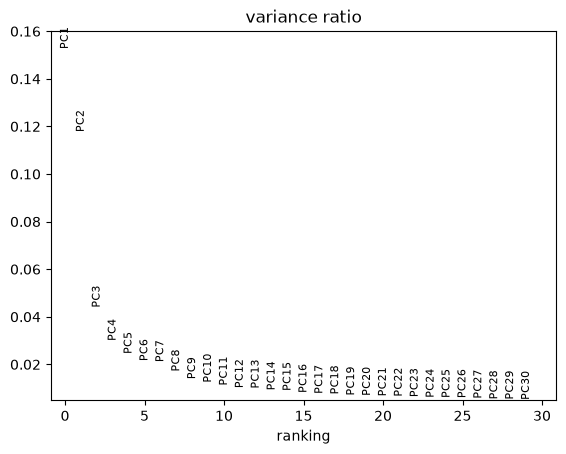

In [8]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_hvg, n_pcs=30, log=False)

In [9]:
# Perform PCA, compute neighbors, and run Leiden clustering on the pseudobulk LFC data
sc.pp.pca(lfc_adata_hvg, n_comps=6)
sc.pp.neighbors(lfc_adata_hvg)
sc.tl.leiden(lfc_adata_hvg)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_300668/1136382900.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(lfc_adata_hvg)


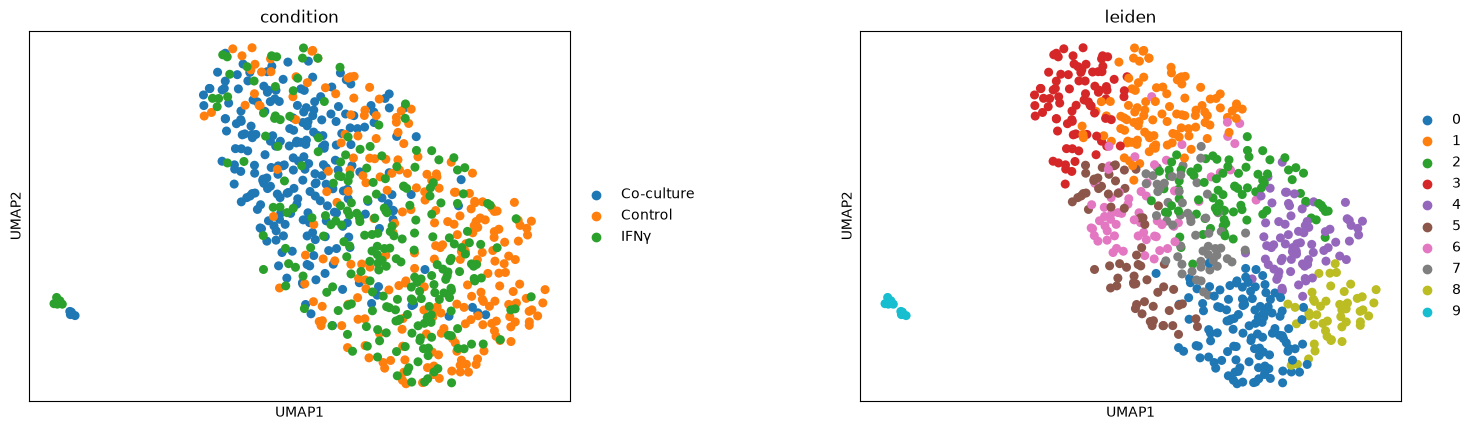

In [10]:
sc.tl.umap(lfc_adata_hvg)
sc.pl.umap(lfc_adata_hvg, color=['condition', 'leiden'], wspace=0.4)

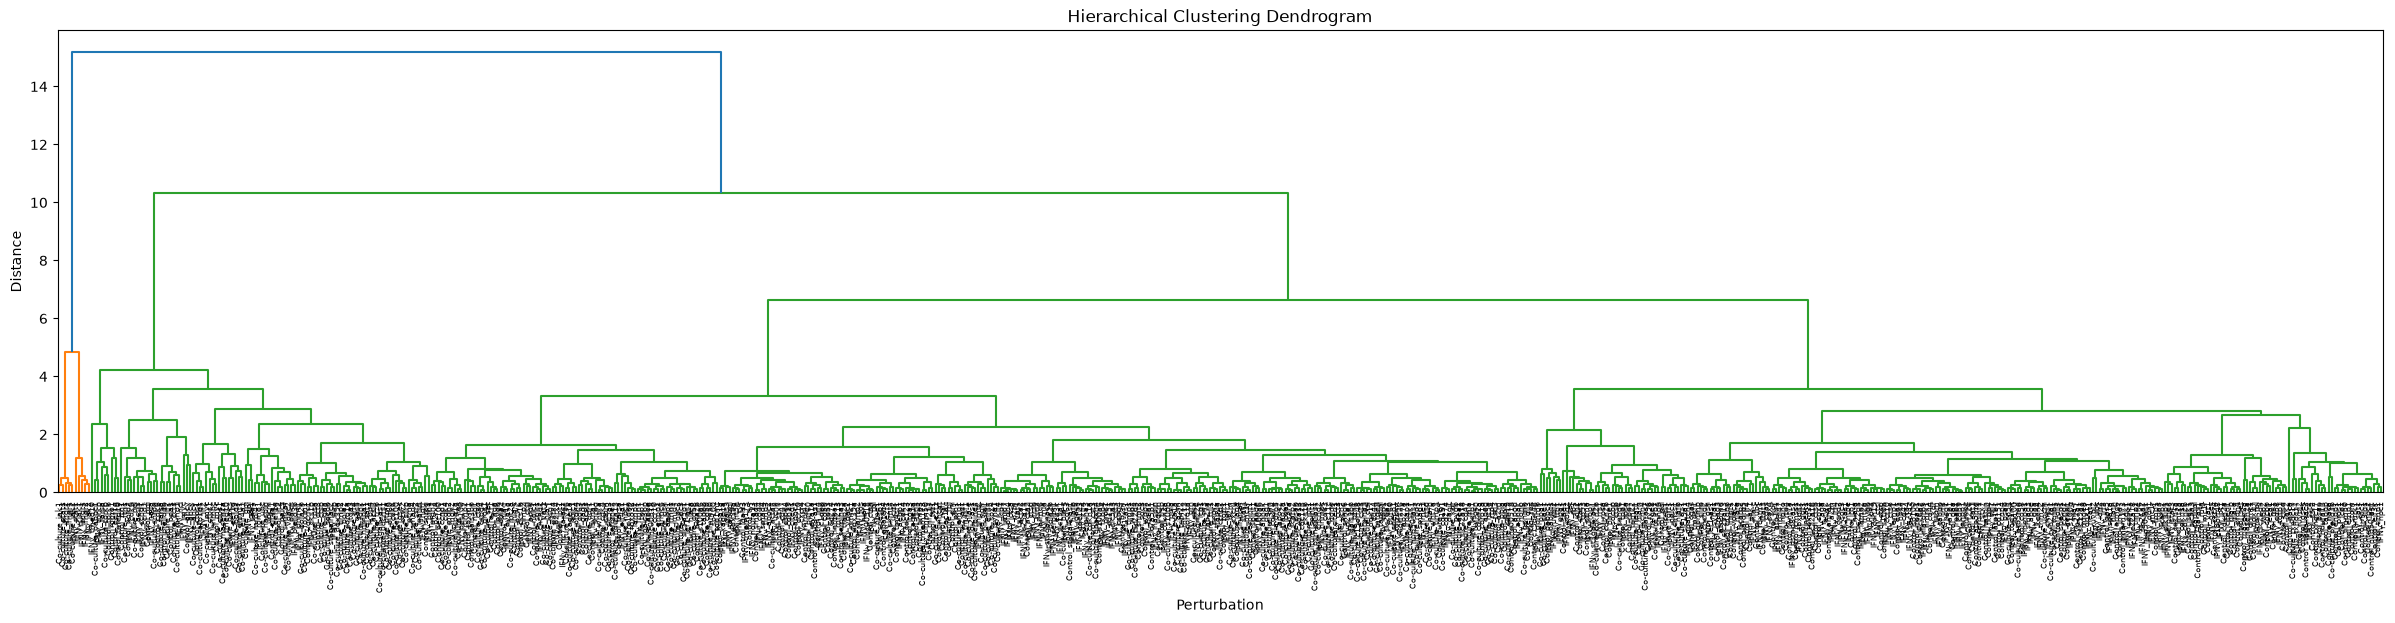

In [11]:
# --- Hierarchical Clustering ---
linkage_data = linkage(lfc_adata_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data, color_threshold=15, labels=lfc_adata_hvg.obs.index, leaf_rotation=90, leaf_font_size=6)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

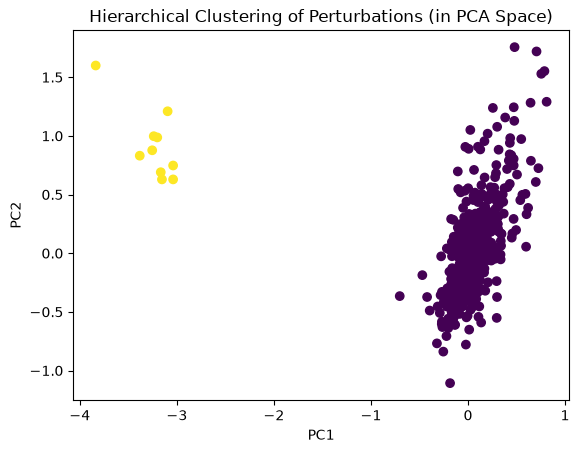

In [12]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
lfc_adata_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster.fit_predict(lfc_adata_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_hvg.obsm['X_pca'][:, 0], lfc_adata_hvg.obsm['X_pca'][:, 1], c=lfc_adata_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

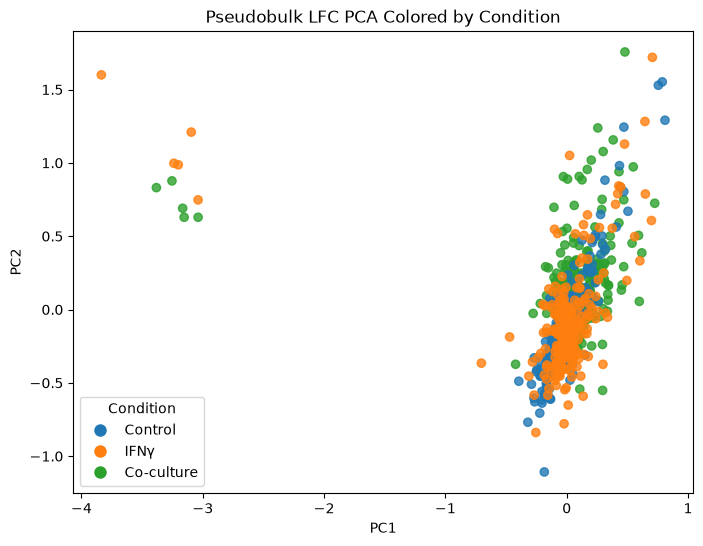

In [13]:
cond_color_map = {
    "Control": "#1f77b4",    # Blue
    "IFNγ": "#ff7f0e",       # Orange
    "Co-culture": "#2ca02c",  # Green
}

# Map the condition string column to hex color codes
colors = lfc_adata_hvg.obs['condition'].map(cond_color_map)

plt.figure(figsize=(8, 6))
plt.scatter(
    lfc_adata_hvg.obsm['X_pca'][:, 0], 
    lfc_adata_hvg.obsm['X_pca'][:, 1], 
    c=colors, 
    alpha=0.8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pseudobulk LFC PCA Colored by Condition")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=key, markersize=10, markerfacecolor=color) for key, color in cond_color_map.items()], title="Condition")

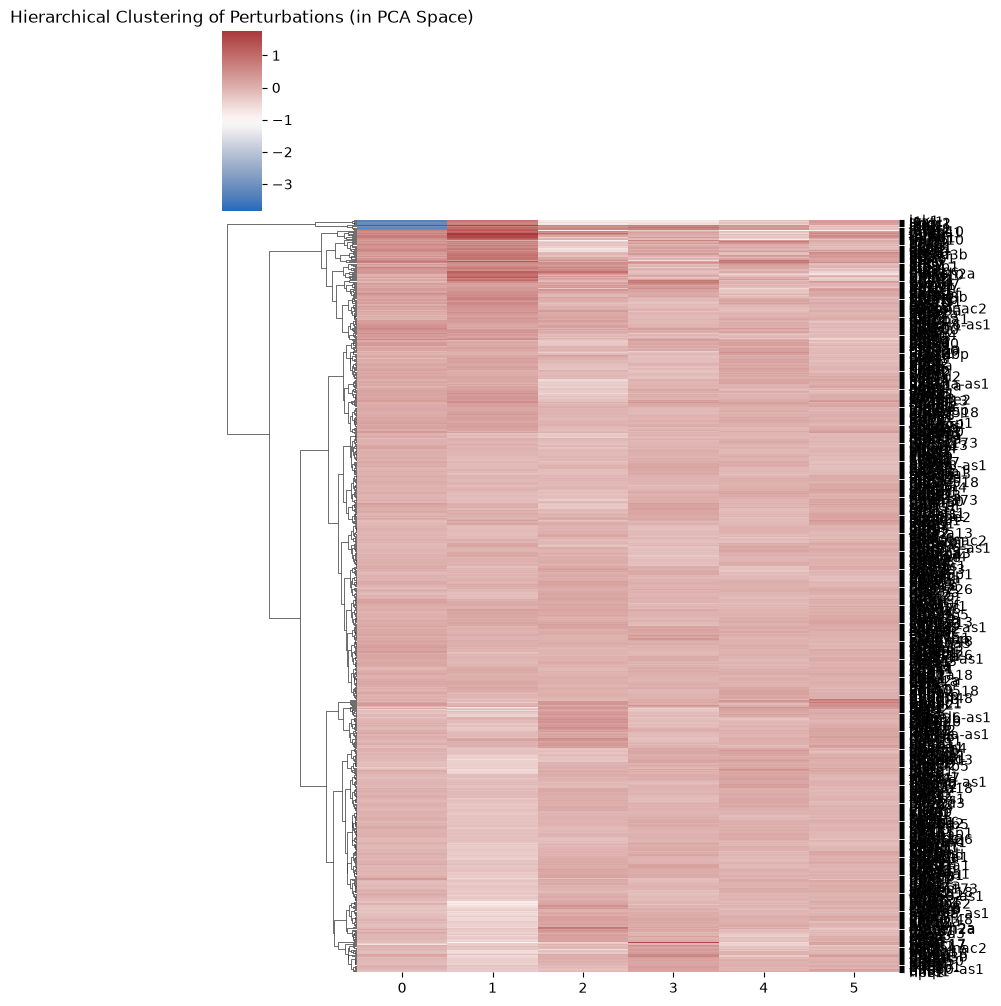

In [14]:
sns.clustermap(
    lfc_adata_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space)")
plt.show()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


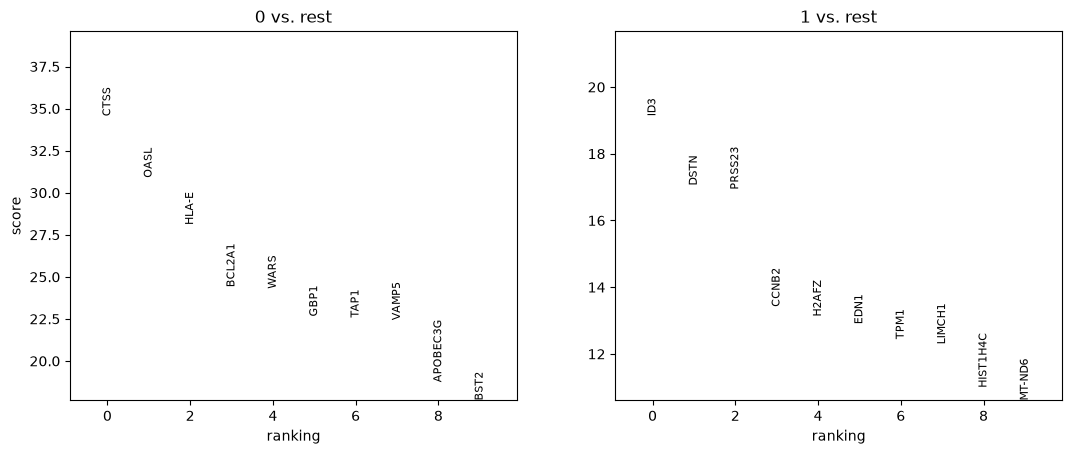

In [15]:
# change to categorical for rank_genes_groups
lfc_adata_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_hvg.obs['cluster_pca_hierarchical'].astype('category')

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_hvg, groupby='cluster_pca_hierarchical', method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_hvg, n_genes=10, sharey=False)

In [16]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_hvg.obs[
        lfc_adata_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 0 (Total: 701) ---
['a2m', 'acsl3', 'acta2', 'aebp1', 'aga', 'ahcy', 'ahnak', 'apoc2', 'apod', 'apoe', 'armc6', 'atp1b1', 'atp5md', 'b2m', 'bola2']

--- Cluster 1 (Total: 10) ---
['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1', 'ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1']


## Cluster condition seperatly

### Control

In [28]:
adata_control_hvg = adata_control[:, adata_control.var["highly_variable"]].copy()

lfc_adata_control_hvg = compute_pseudobulk_lfc(
    adata=adata_control_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=15,
    pseudocount=1.0,
    data_type='counts'
)


/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


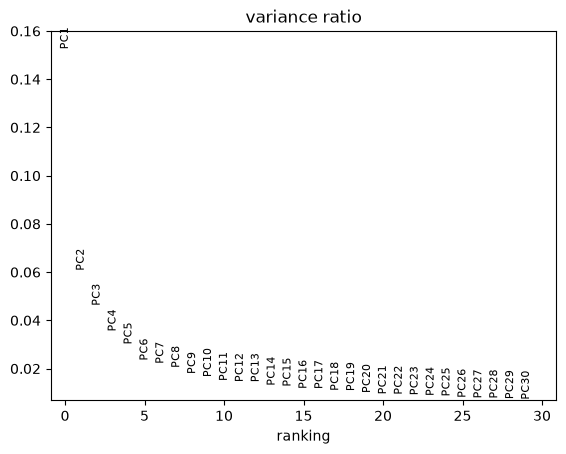

In [20]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_control_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_control_hvg, n_pcs=30, log=False)

In [21]:
sc.pp.pca(lfc_adata_control_hvg, n_comps=6)

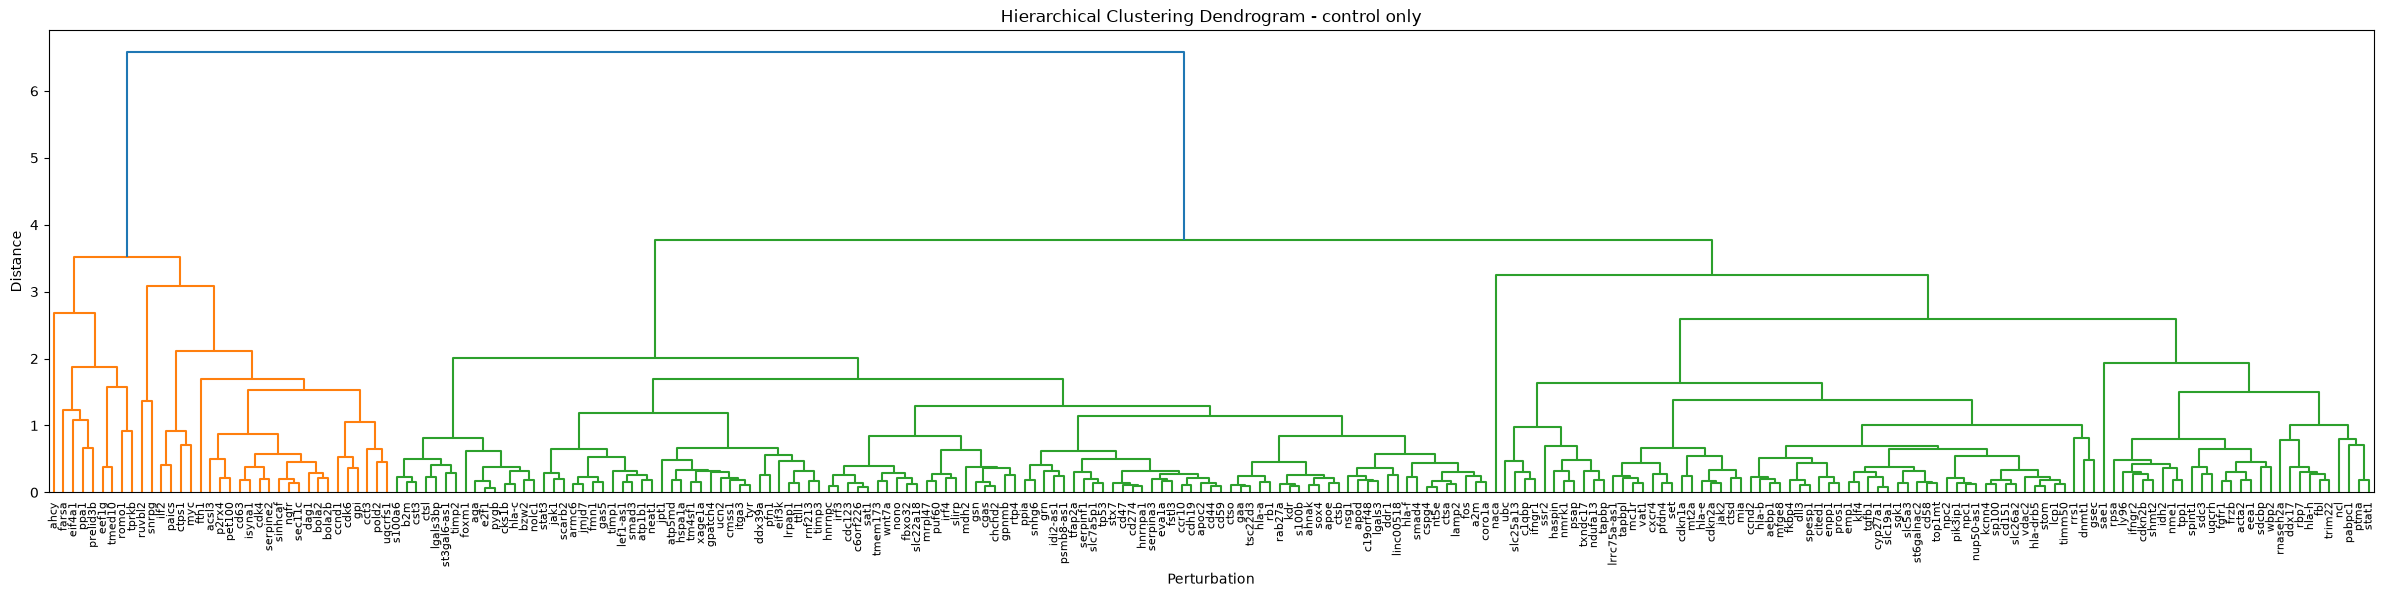

In [22]:
# --- Hierarchical Clustering ---
linkage_data_control = linkage(lfc_adata_control_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data_control, color_threshold=6, labels=lfc_adata_control_hvg.obs["perturbation"].tolist(), leaf_rotation=90, leaf_font_size=8)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram - control only")

plt.show()

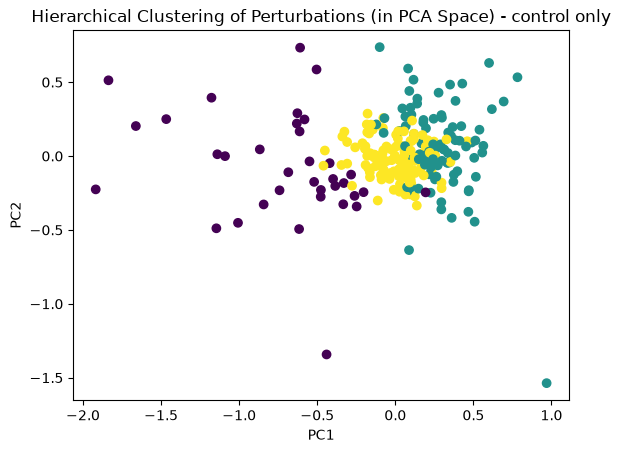

In [24]:
hierarchical_cluster_control = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
lfc_adata_control_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster_control.fit_predict(lfc_adata_control_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_control_hvg.obsm['X_pca'][:, 0], lfc_adata_control_hvg.obsm['X_pca'][:, 1], c=lfc_adata_control_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - control only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

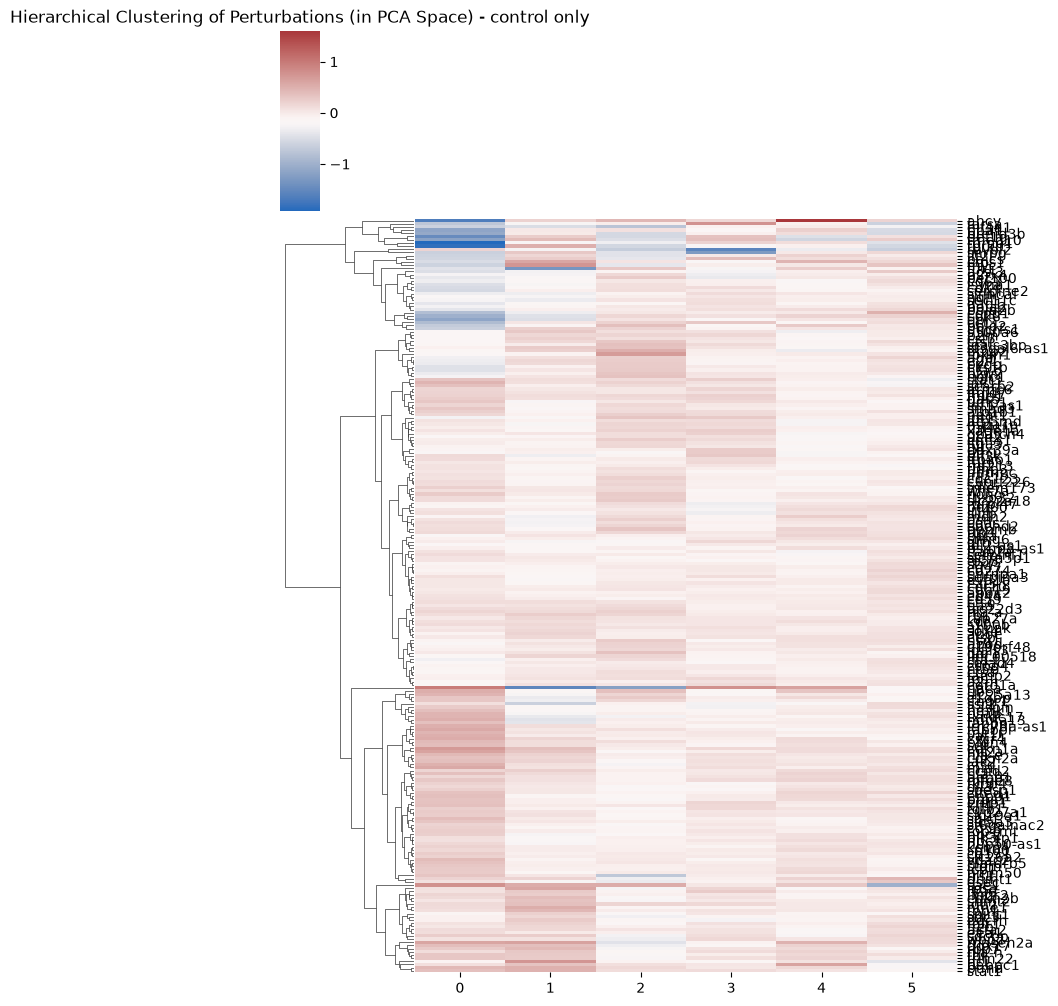

In [25]:
sns.clustermap(
    lfc_adata_control_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_control_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - control only")
plt.show()

Valid clusters with > 3 samples: ['2', '1', '0']


/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


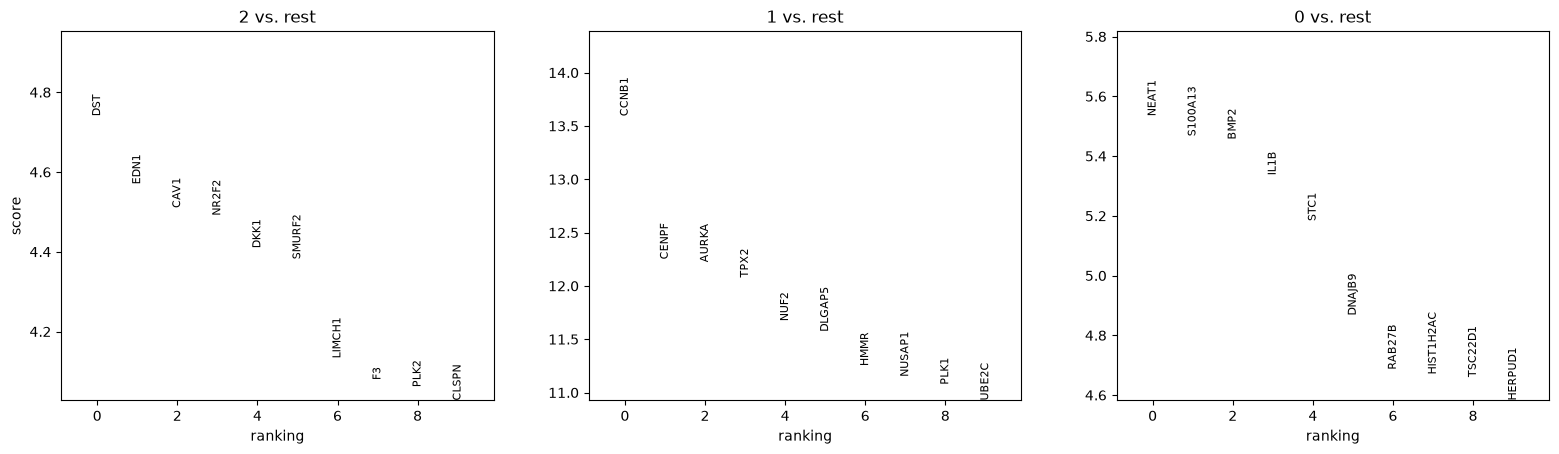

In [26]:
# change to categorical for rank_genes_groups
lfc_adata_control_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_control_hvg.obs['cluster_pca_hierarchical'].astype("str").astype('category')

cluster_counts = lfc_adata_control_hvg.obs['cluster_pca_hierarchical'].value_counts()

valid_groups = cluster_counts[cluster_counts > 3].index.tolist()

print(f"Valid clusters with > 3 samples: {valid_groups}")

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_control_hvg, groupby='cluster_pca_hierarchical', groups=valid_groups, method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_control_hvg, n_genes=10, sharey=False)

In [27]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_control_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_control_hvg.obs[
        lfc_adata_control_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 2 (Total: 112) ---
['a2m', 'aga', 'ahnak', 'apoc2', 'apod', 'apoe', 'armc6', 'atp1b1', 'atp5md', 'b2m', 'bzw2', 'c19orf48', 'c6orf226', 'ccr10', 'cd274']

--- Cluster 0 (Total: 35) ---
['acsl3', 'ahcy', 'bola2', 'bola2b', 'ccnd1', 'cct3', 'cd63', 'cdk4', 'cdk6', 'ctps1', 'dag1', 'eef1g', 'eif4a1', 'farsa', 'fth1']

--- Cluster 1 (Total: 90) ---
['acta2', 'aebp1', 'c1qbp', 'ccnd2', 'cd151', 'cd58', 'cdkn1a', 'cdkn2a', 'cdkn2b', 'cited1', 'ctsd', 'cxcr4', 'cyp27a1', 'ddx17', 'dll3']


### co-culture

In [30]:
adata_coculture_hvg = adata_coculture[:, adata_coculture.var["highly_variable"]].copy()

lfc_adata_coculture_hvg = compute_pseudobulk_lfc(
    adata=adata_coculture_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=15,
    pseudocount=1.0,
    data_type='counts'
)


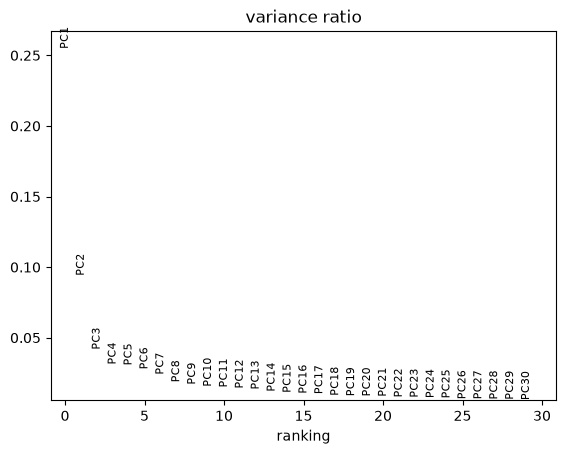

In [31]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_coculture_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_coculture_hvg, n_pcs=30, log=False)

In [32]:
sc.pp.pca(lfc_adata_coculture_hvg, n_comps=4)

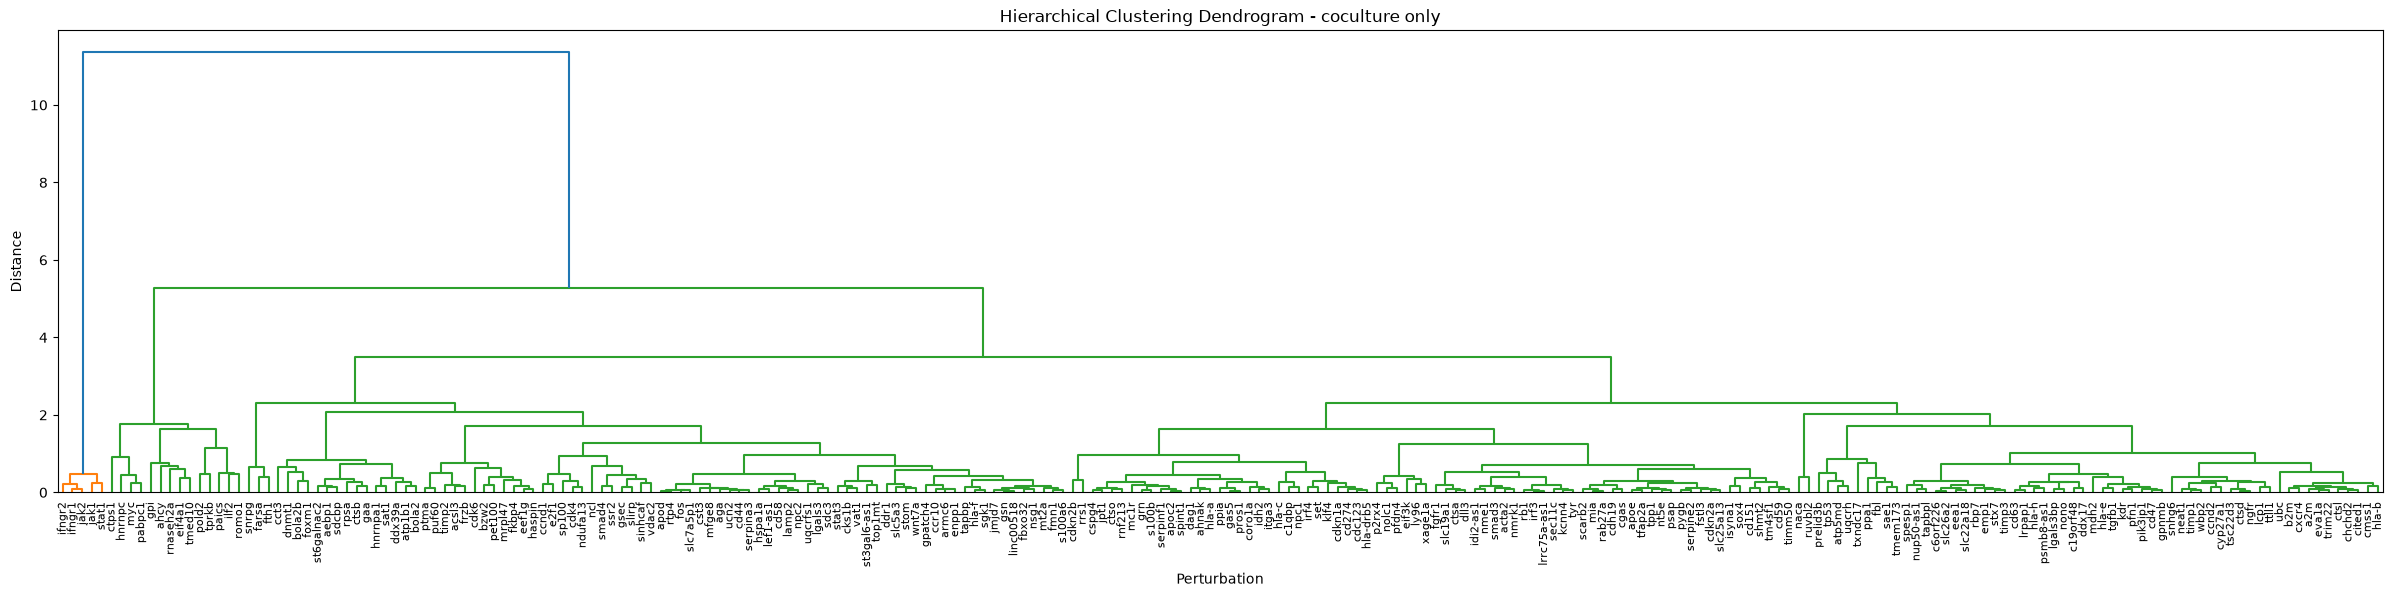

In [33]:
# --- Hierarchical Clustering ---
linkage_data_coculture = linkage(lfc_adata_coculture_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data_coculture, color_threshold=8, labels=lfc_adata_coculture_hvg.obs["perturbation"].tolist(), leaf_rotation=90, leaf_font_size=8)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram - coculture only")

plt.show()

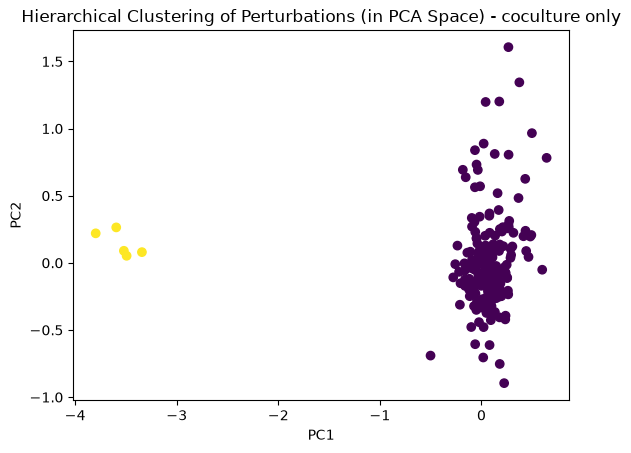

In [34]:
hierarchical_cluster_coculture = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster_coculture.fit_predict(lfc_adata_coculture_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_coculture_hvg.obsm['X_pca'][:, 0], lfc_adata_coculture_hvg.obsm['X_pca'][:, 1], c=lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - coculture only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

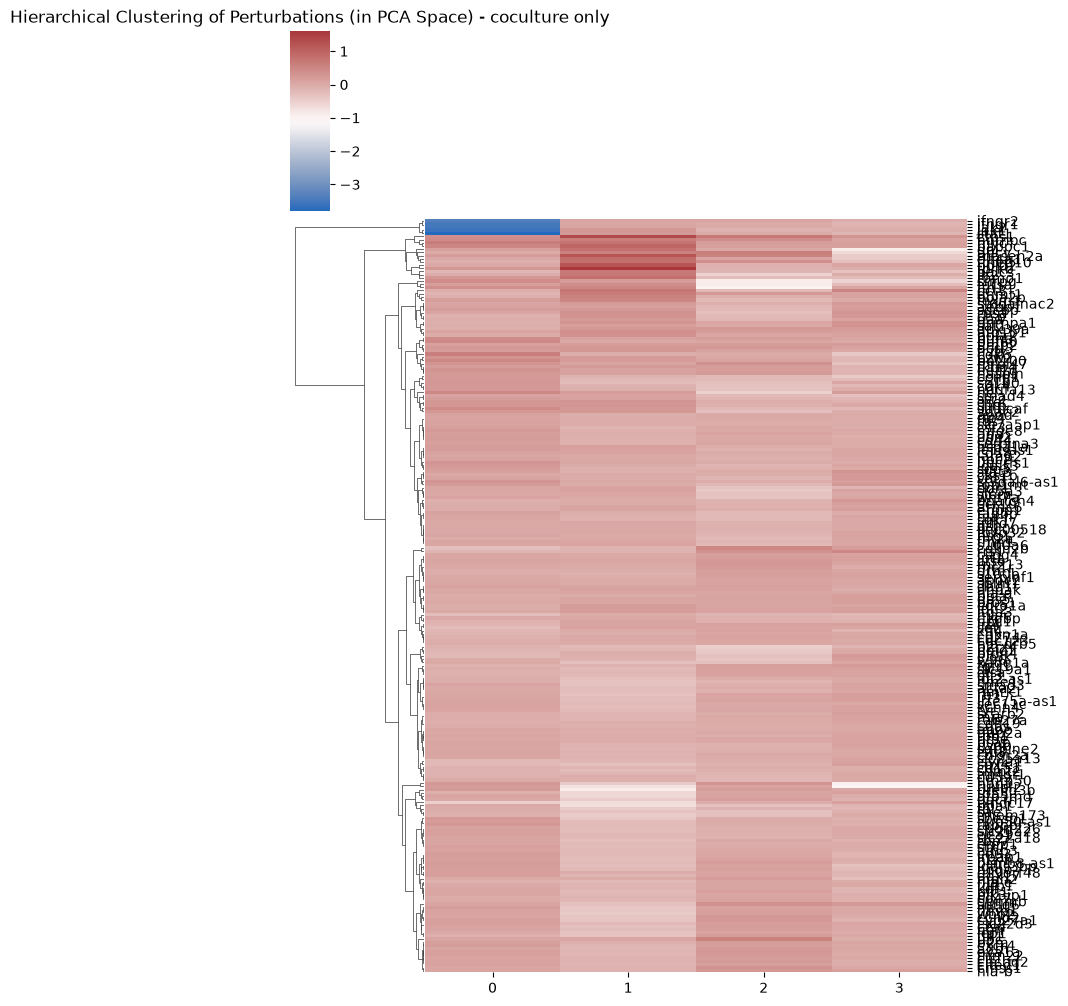

In [35]:
sns.clustermap(
    lfc_adata_coculture_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_coculture_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - coculture only")
plt.show()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


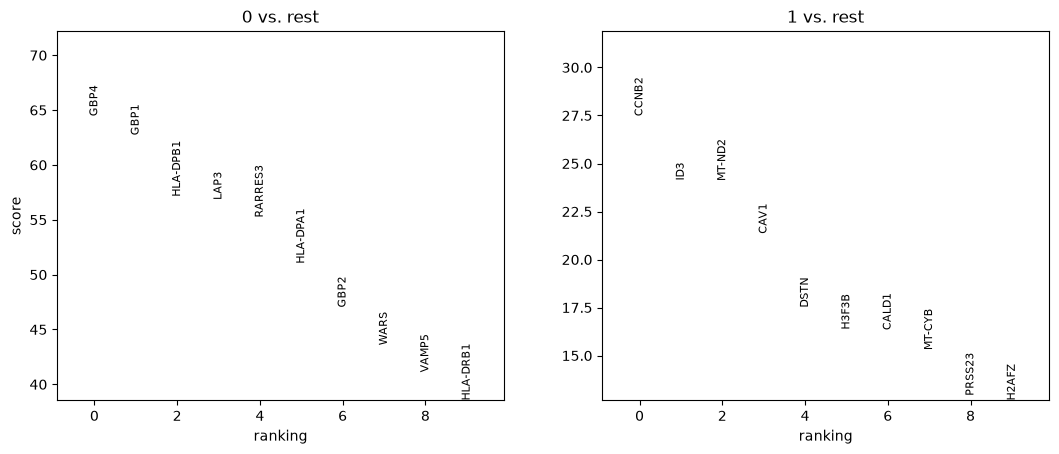

In [36]:
# change to categorical for rank_genes_groups
lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'].astype("str").astype('category')

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_coculture_hvg, groupby='cluster_pca_hierarchical', method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_coculture_hvg, n_genes=10, sharey=False)

In [37]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_coculture_hvg.obs[
        lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 0 (Total: 232) ---
['a2m', 'acsl3', 'acta2', 'aebp1', 'aga', 'ahcy', 'ahnak', 'apoc2', 'apod', 'apoe', 'armc6', 'atp1b1', 'atp5md', 'b2m', 'bola2']

--- Cluster 1 (Total: 5) ---
['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1']


### IFNg

In [39]:
adata_ifng_hvg = adata_ifng[:, adata_ifng.var["highly_variable"]].copy()

lfc_adata_ifng_hvg = compute_pseudobulk_lfc(
    adata=adata_ifng_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=15,
    pseudocount=1.0,
    data_type='counts'
)


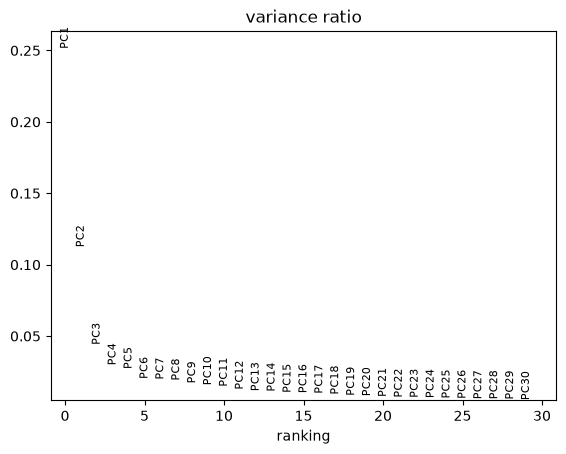

In [40]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_ifng_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_ifng_hvg, n_pcs=30, log=False)

In [41]:
sc.pp.pca(lfc_adata_ifng_hvg, n_comps=4)

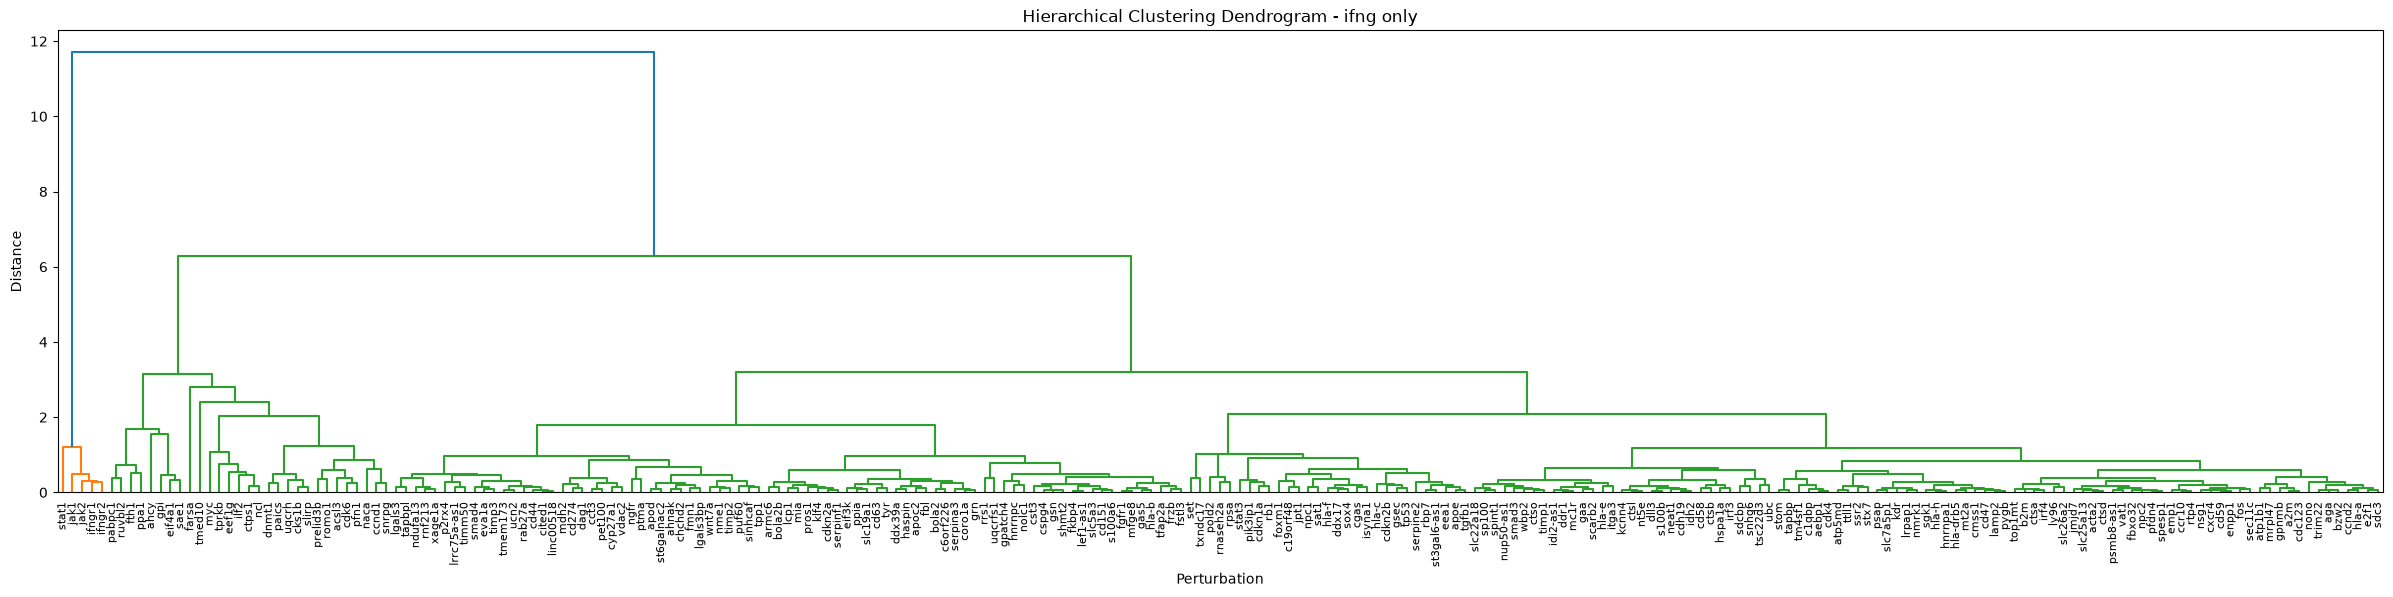

In [42]:
# --- Hierarchical Clustering ---
linkage_data_ifng = linkage(lfc_adata_ifng_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data_ifng, color_threshold=10, labels=lfc_adata_ifng_hvg.obs["perturbation"].tolist(), leaf_rotation=90, leaf_font_size=8)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram - ifng only")

plt.show()

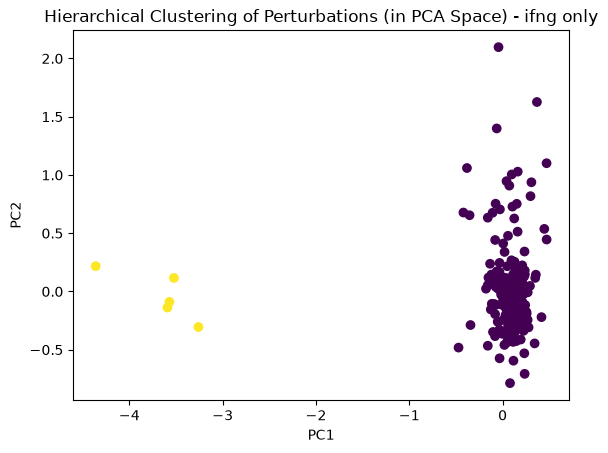

In [43]:
hierarchical_cluster_ifng = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster_ifng.fit_predict(lfc_adata_ifng_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_ifng_hvg.obsm['X_pca'][:, 0], lfc_adata_ifng_hvg.obsm['X_pca'][:, 1], c=lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - ifng only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

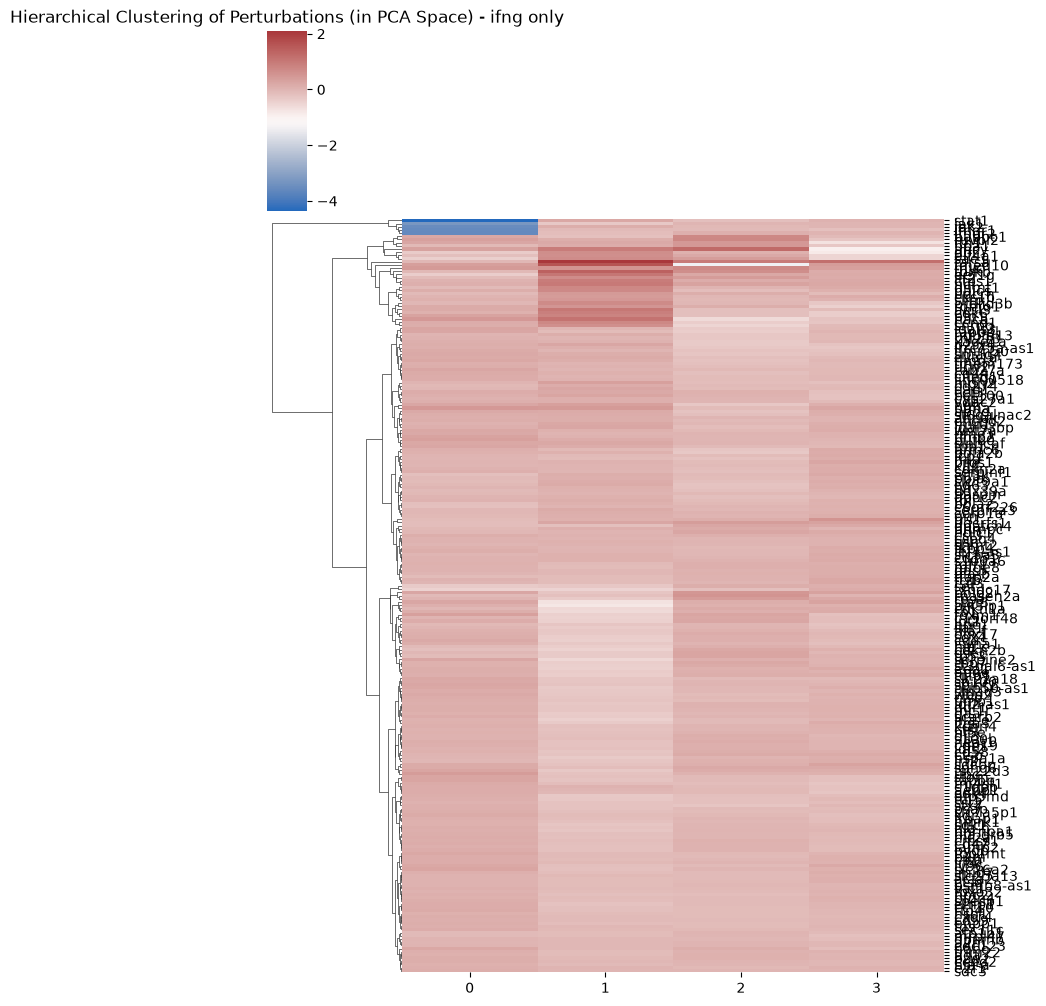

In [44]:
sns.clustermap(
    lfc_adata_ifng_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_ifng_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - ifng only")
plt.show()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


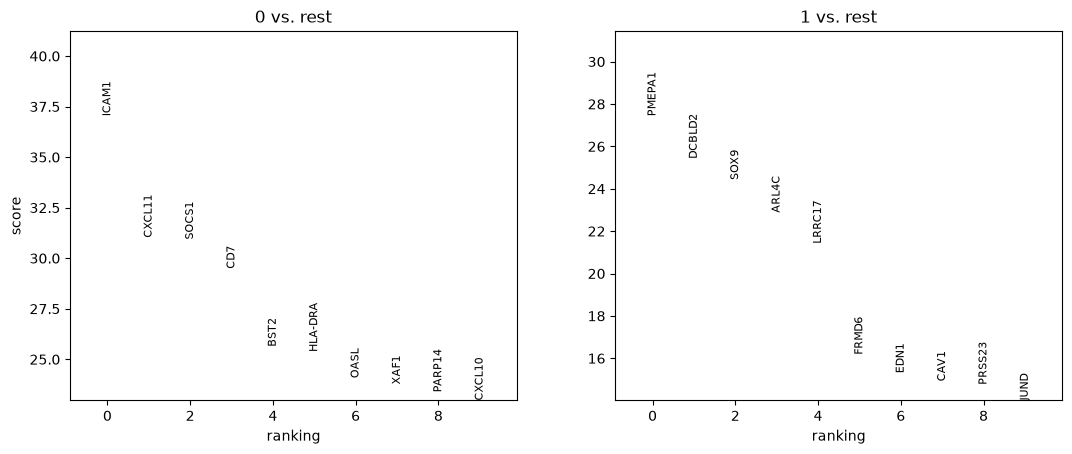

In [45]:
# change to categorical for rank_genes_groups
lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'].astype("str").astype('category')

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_ifng_hvg, groupby='cluster_pca_hierarchical', method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_ifng_hvg, n_genes=10, sharey=False)

In [46]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_ifng_hvg.obs[
        lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 0 (Total: 232) ---
['a2m', 'acsl3', 'acta2', 'aebp1', 'aga', 'ahcy', 'ahnak', 'apoc2', 'apod', 'apoe', 'armc6', 'atp1b1', 'atp5md', 'b2m', 'bola2']

--- Cluster 1 (Total: 5) ---
['ifngr1', 'ifngr2', 'jak1', 'jak2', 'stat1']
